In [1]:
# pip install cdsapi xarray netCDF4 numpy pandas matplotlib scipy metpy


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [14]:
import cdsapi

    # "variable": [
    #     "temperature",
    #     "specific_humidity",
    #     "geopotential",
    #     "vertical_velocity"
    # ]

dataset = "reanalysis-era5-pressure-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["vertical_velocity"],
    "year": ["2025"],
    "month": ["05"],
    "day": [
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "pressure_level": [
        "100", "200", "300",
        "400", "450", "500",
        "550", "600", "650",
        "700", "750", "800",
        "850", "900", "925",
        "950", "975", "1000"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [14, 76, 12, 78]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


2026-04-17 02:09:47,438 INFO Request ID is c8a1fecd-4fa3-42ec-9c82-4cb78cd9422f
2026-04-17 02:09:47,553 INFO status has been updated to accepted
2026-04-17 02:10:01,325 INFO status has been updated to running
2026-04-17 02:24:11,679 INFO status has been updated to successful


'9cb35efa69db3eb08fba3ea6b8c71fc5.nc'

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from metpy.calc import virtual_potential_temperature
from metpy.units import units

/Users/bidyut/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


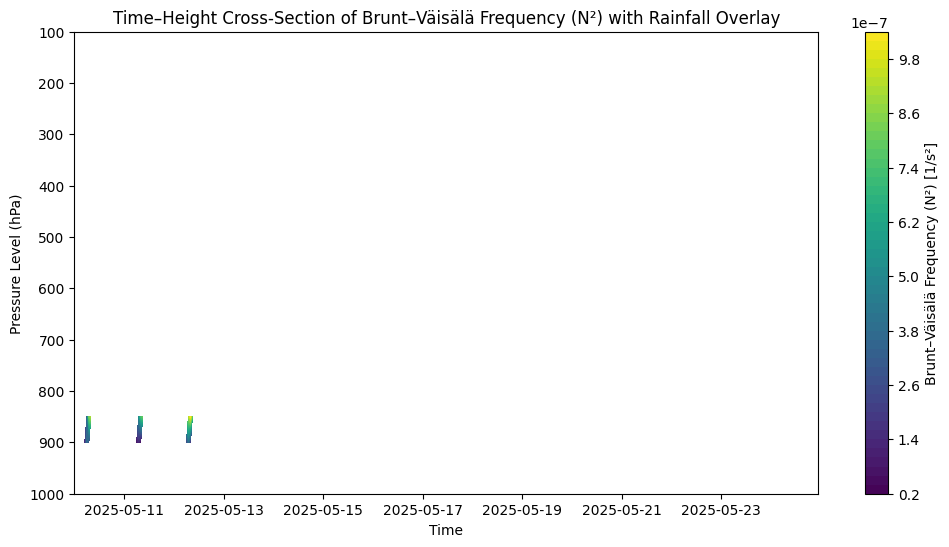

In [31]:
#Load datasets
ds_geopotential = xr.open_dataset("Blore_19May2025_event_geopotential.nc")
ds_vertical_velocity = xr.open_dataset("Blore_19May2025_event_vertical_velocity.nc")
ds_temperature = xr.open_dataset("Blore_19May2025_event_temperature.nc")
ds_specific_humidity = xr.open_dataset("Blore_19May2025_event_specific_humidity.nc")


# Area mean
ds_geopotential_mean = ds_geopotential.mean(dim=["latitude", "longitude"])
ds_vertical_velocity_mean = ds_vertical_velocity.mean(dim=["latitude", "longitude"])
ds_temperature_mean = ds_temperature.mean(dim=["latitude", "longitude"])
ds_specific_humidity_mean = ds_specific_humidity.mean(dim=["latitude", "longitude"])

# Calculate virtual potential temperature
temperature = ds_temperature_mean["t"] * units.kelvin
specific_humidity = ds_specific_humidity_mean["q"] * units.dimensionless
pressure = ds_temperature_mean["pressure_level"] * units.hPa
virtual_potential_temp = virtual_potential_temperature(pressure,temperature,specific_humidity)

# calculate Vertical gradient dθᵥ/dz and Brunt–Väisälä frequency N²
g = 9.81 * units("m/s^2")
dz = np.gradient(ds_temperature_mean["pressure_level"].values) * 100  # Convert hPa to Pa
dtheta_v_dz = np.gradient(virtual_potential_temp, axis=0) / dz[:, np.newaxis]
N_squared = (g / virtual_potential_temp.data).magnitude * dtheta_v_dz

#Plot time–height N² with rainfall overlay
plt.figure(figsize=(12, 6))
time = ds_temperature_mean["valid_time"].values
pressure_levels = ds_temperature_mean["pressure_level"].values
N_squared_masked = np.ma.masked_where(N_squared < 0, N_squared)
plt.contourf(time, pressure_levels, N_squared_masked, levels=50, cmap="viridis")
plt.colorbar(label="Brunt–Väisälä Frequency (N²) [1/s²]")
plt.gca().invert_yaxis()
plt.xlabel("Time")
plt.ylabel("Pressure Level (hPa)")
plt.title("Time–Height Cross-Section of Brunt–Väisälä Frequency (N²) with Rainfall Overlay")
plt.show()



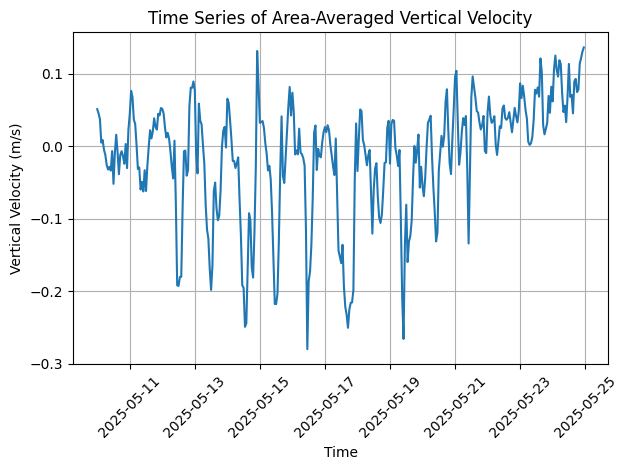

In [ ]:
plt.plot(ds_vertical_velocity_mean["valid_time"].values,
		 ds_vertical_velocity_mean["w"].mean(dim="pressure_level").values)
#rotate xtix labels for better visibility
plt.xticks(rotation=45)
#make yaxis label bigger
plt.yticks(fontsize=12)
plt.xlabel("Time")
plt.ylabel("Vertical Velocity (m/s)")
plt.title("Time Series of Area-Averaged Vertical Velocity")
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
ds_specific_humidity_mean

<xarray.Dataset> Size: 35kB
Dimensions:         (valid_time: 360, pressure_level: 18)
Coordinates:
    number          int64 8B ...
  * valid_time      (valid_time) datetime64[ns] 3kB 2025-05-10 ... 2025-05-24...
  * pressure_level  (pressure_level) float64 144B 1e+03 975.0 ... 200.0 100.0
    expver          (valid_time) <U4 6kB ...
Data variables:
    q               (valid_time, pressure_level) float32 26kB 0.01475 ... 2.0...